In [1]:
from sf_workingdir_lilly.dmlab.custom_esn_analysis import get_hidden_states_iso_feat
import torch
import numpy as np
import matplotlib.pyplot as plt


In [2]:
time_steps = 70
spectral_radius = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.92, 0.95, 0.97, 0.99]
Hippo_n_feature = 16
Hippo_R = 8
Hippo_L = 64
trial=1
fixed_whh=True
fixed_wih=True

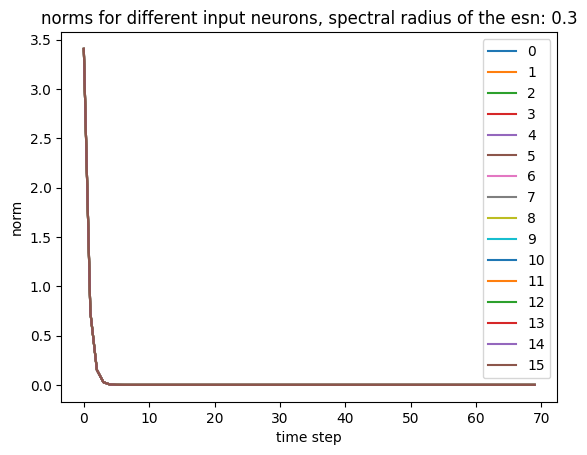

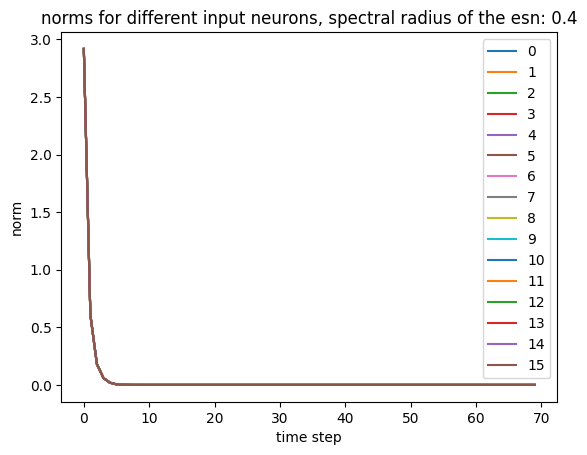

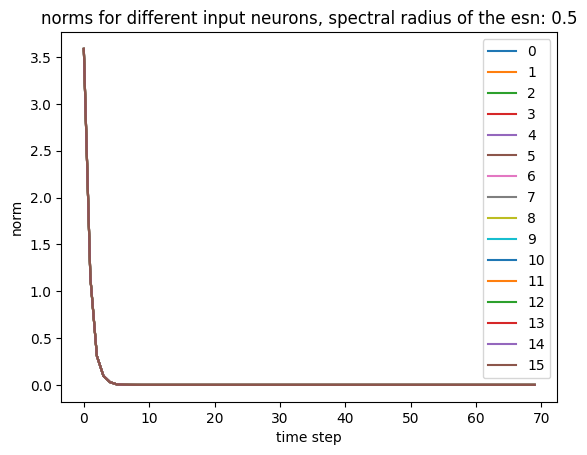

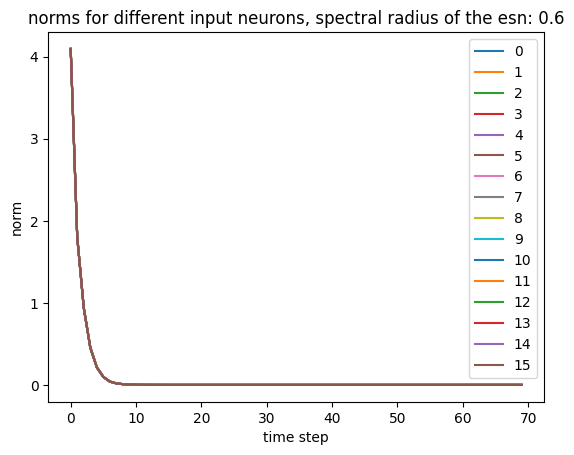

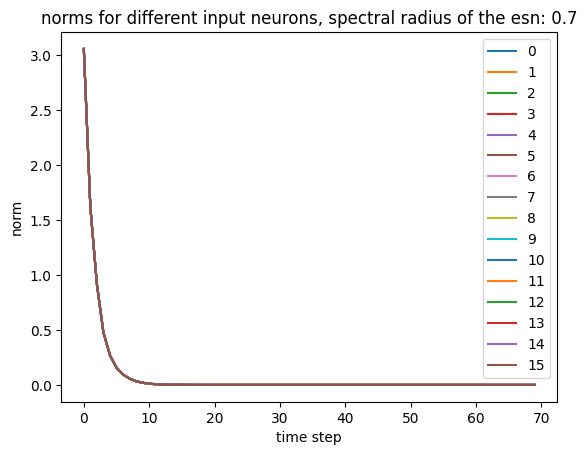

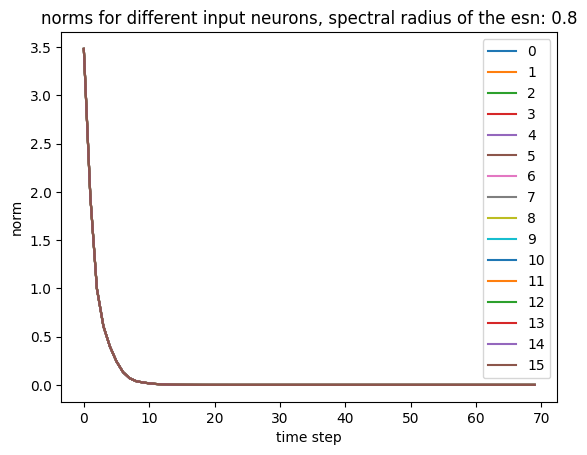

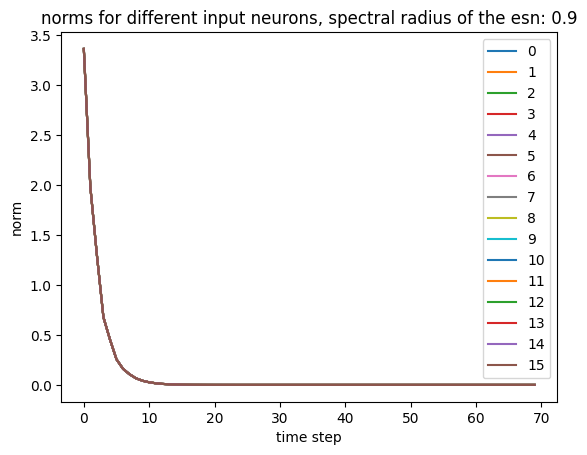

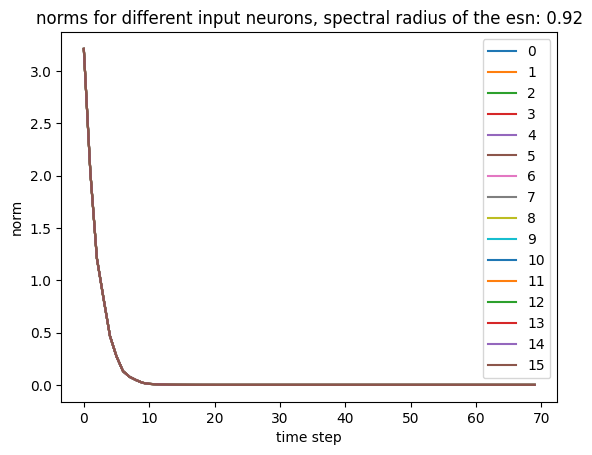

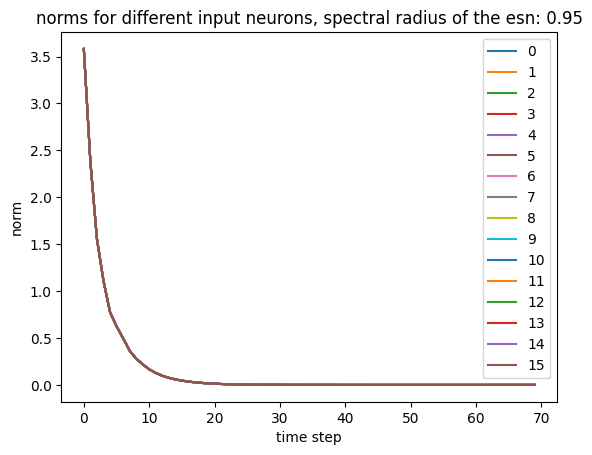

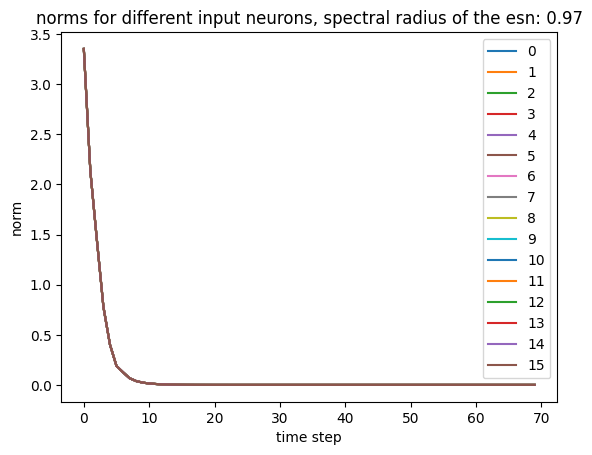

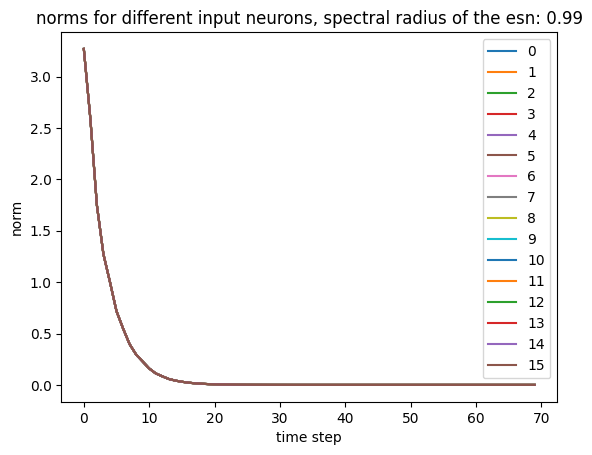

In [3]:
# plot the norms over different input neurons to see for how long the input information stays in the esn

neuron_norms_for_srs = np.zeros((len(spectral_radius), Hippo_n_feature,time_steps))

for sr_i, sr in enumerate(spectral_radius):
    # create a (input_index, time_steps) matrix for each spectral radius - values in the matrix are the norms at this input index at that tiem - and create a plot where the norms are plotted against the time
    #neuron_norms = np.zeros((Hippo_n_feature,time_steps))
    plt.figure()
    for i in range(Hippo_n_feature):
        hs = get_hidden_states_iso_feat(time_steps, sr, Hippo_n_feature, Hippo_R, Hippo_L, trial, fixed_whh, fixed_wih, input_idx=i)  # size: (time_steps, hidden_size)
        norms = hs.norm(dim=1)
        #neuron_norms[i,:] = norms
        neuron_norms_for_srs[sr_i,i,:] = norms
        plt.plot(norms, label=f'{i}')
    
    plt.title(f'norms for different input neurons, spectral radius of the esn: {sr}')
    plt.xlabel('time step')
    plt.ylabel('norm')
    plt.legend()
    

     

In [4]:
# define a threshold and see at which time step the norms cross the threshold
# with this you can see at which time step there is basically no more information of the original input in the system

threshold = 0.05

threshold_was_reached = np.zeros((len(spectral_radius), Hippo_n_feature))

for sr_i, sr in enumerate(spectral_radius):
    for i in range(Hippo_n_feature):
        current_norms = neuron_norms_for_srs[sr_i,i,:]
        threshold_idx = np.where(current_norms <= threshold)
        threshold_was_reached[sr_i,i] = threshold_idx[0][0]
    

In [5]:
# at what time step was the threshold reached for each spectral radius - for each different feature that received a non zero input in the beginning

print(threshold_was_reached)
print(threshold_was_reached.mean(axis=1))

[[ 3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.]
 [ 4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.]
 [ 4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.]
 [ 6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.]
 [ 8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.]
 [ 8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.]
 [ 9.  9.  9.  9.  9.  9.  9.  9.  9.  9.  9.  9.  9.  9.  9.  9.]
 [ 8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.]
 [15. 15. 15. 15. 15. 15. 15. 15. 15. 15. 15. 15. 15. 15. 15. 15.]
 [ 8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.]
 [14. 14. 14. 14. 14. 14. 14. 14. 14. 14. 14. 14. 14. 14. 14. 14.]]
[ 3.  4.  4.  6.  8.  8.  9.  8. 15.  8. 14.]


In [6]:
threshold = 0.0001

threshold_was_reached = np.zeros((len(spectral_radius), Hippo_n_feature))

for sr_i, sr in enumerate(spectral_radius):
    for i in range(Hippo_n_feature):
        current_norms = neuron_norms_for_srs[sr_i,i,:]
        threshold_idx = np.where(current_norms <= threshold)
        threshold_was_reached[sr_i,i] = threshold_idx[0][0]

print(threshold_was_reached)
print(threshold_was_reached.mean(axis=1))

[[ 6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.]
 [ 9.  9.  9.  9.  9.  9.  9.  9.  9.  9.  9.  9.  9.  9.  9.  9.]
 [ 9.  9.  9.  9.  9.  9.  9.  9.  9.  9.  9.  9.  9.  9.  9.  9.]
 [14. 14. 14. 14. 14. 14. 14. 14. 14. 14. 14. 14. 14. 14. 14. 14.]
 [19. 19. 19. 19. 19. 19. 19. 19. 19. 19. 19. 19. 19. 19. 19. 19.]
 [20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20.]
 [21. 21. 21. 21. 21. 21. 21. 21. 21. 21. 21. 21. 21. 21. 21. 21.]
 [18. 18. 18. 18. 18. 18. 18. 18. 18. 18. 18. 18. 18. 18. 18. 18.]
 [40. 40. 40. 40. 40. 40. 40. 40. 40. 40. 40. 40. 40. 40. 40. 40.]
 [20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20.]
 [33. 33. 33. 33. 33. 33. 33. 33. 33. 33. 33. 33. 33. 33. 33. 33.]]
[ 6.  9.  9. 14. 19. 20. 21. 18. 40. 20. 33.]
